## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)
dataset_monthly

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,98.865052,0
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,68.808664,0
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,6.674636,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,NaN,NaN,31.010417,0
3,21.719540,39.504234,2,2010,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,4.554370,7.839973,1.268766,-3.042901,13.286678,3.211945,2.916904,NaN,NaN,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,310.442081,79.217105,151.965634,370.323392,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,445.038062,0
4,22.405497,39.703383,2,2010,2010-02,EL61,θεσσαλια,EL612,λαρισα,0.321330,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.868979,11.048597,2.689361,-2.894380,15.076065,6.001348,4.861217,NaN,NaN,10.127192,9.095389,NaN,NaN,1.875504,0.537745,NaN,NaN,7.380415,206.651624,51.045338,97.899665,193.962831,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,285.415162,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,22.405497,39.703383,11,2022,2022-11,EL61,θεσσαλια,EL612,λαρισα,0.268091,-0.017647,-0.237168,0.017647,0.256220,-0.012099,-0.223224,0.012099,0.047753,0.055676,0.044192,0.055676,17.333333,22.666667,49.275362,884.290505,40.0,-6.0,46.0

<AxesSubplot:>

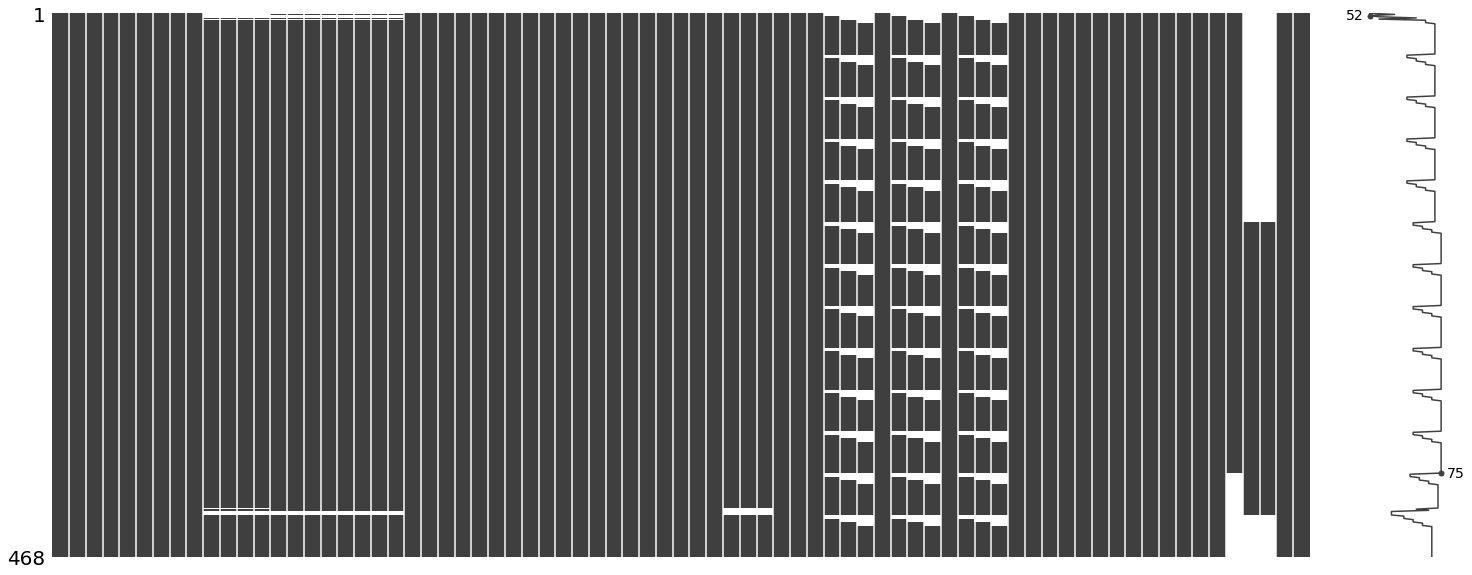

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,2.1368
1,ndmi,2.1368
2,ndwi,2.1368
3,ndbi,2.1368
4,ndvi_mean,1.7094
...,...,...
22,lst_mar_night_mean,16.6667
23,lst_apr_night_mean,25.0000
24,MIO_EUR,15.3846
25,L_TOTAL,46.1538


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst'].min()
        mean_temp_q1 = q1_df['lst'].mean()
        max_temp_q1 = q1_df['lst'].max()
        prec_q1 = q1_df['rainfall'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst'].min()
        mean_temp_q2 = q2_df['lst'].mean()
        max_temp_q2 = q2_df['lst'].max()
        prec_q2 = q2_df['rainfall'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst'].min()
        mean_temp_q3 = q3_df['lst'].mean()
        max_temp_q3 = q3_df['lst'].max()
        prec_q3 = q3_df['rainfall'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst'].min()
        mean_temp_q4 = q4_df['lst'].mean()
        max_temp_q4 = q4_df['lst'].max()
        prec_q4 = q4_df['rainfall'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,"καρδιτσα, τρικαλα",2010,3.882783,6.253010,10.321877,22.810674,0.365954,-0.165260,0.177493,-0.177493,0.371647,-0.169363,0.178929,-0.178929,0.065184,0.078587,0.080266,0.080266,3.882783,12.585331,22.720765,31.828054,0.449257,-0.252538,0.176848,-0.176848,0.451208,-0.249712,0.180750,-0.180750,0.059637,0.052054,0.063588,0.063588,3.882783,16.586862,27.566454,40.720656,0.468370,-0.285436,0.164908,-0.164908,0.469377,-0.280369,0.169654,-0.169654,0.059794,0.048069,0.063361,0.063361,3.882783,14.890048,27.566454,66.491666,0.437673,-0.229370,0.179965,-0.179965,0.436033,-0.224968,0.181755,-0.181755,0.057491,0.053987,0.061168,0.061168
1,λαρισα,2010,6.047620,8.171462,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.047620,14.411227,25.050329,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.047620,18.645505,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988171,16.777741,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,"μαγνησια, σποραδες",2010,6.674636,8.670540,11.690988,14.116041,0.452884,-0.250841,0.178015,-0.178015,0.451490,-0.260363,0.169616,-0.169616,0.055594,0.052520,0.064438,0.064438,6.674636,14.384084,24.257590,20.803892,0.452695,-0.274591,0.164978,-0.164978,0.449361,-0.272514,0.163769,-0.163769,0.049853,0.038207,0.051734,0.051734,6.674636,18.474015,29.155554,28.164914,0.460711,-0.268199,0.178537,-0.178537,0.447714,-0.258215,0.174607,-0.174607,0.052167,0.041413,0.053332,0.053332,6.674636,16.931607,29.155554,41.250051,0.431217,-0.222728,0.182427,-0.182427,0.419909,-0.211698,0.181693,-0.181693,0.051276,0.047902,0.052765,0.052765
3,"καρδιτσα, τρικαλα",2011,3.686851,5.948136,8.265869,14.428439,0.247676,0.124756,0.332002,-0.332002,0.250039,0.109395,0.319940,-0.319940,0.050979,0.086203,0.061957,0.061957,3.686851,11.693837,22.140834,22.319557,0.354872,-0.061508,0.257492,-0.257492,0.354794,-0.063112,0.255806,-0.255806,0.052500,0.065353,0.058403,0.058403,3.686851,16.075582,26.194276,26.421316,0.397419,-0.147194,0.224026,-0.224026,0.396718,-0.146377,0.223808,-0.223808,0.056012,0.058159,0.061354,0.061354,3.686851,14.301585,26.194276,40.415159,0.380764,-0.151949,0.199359,-0.199359,0.379643,-0.151105,0.199373,-0.199373,0.056902,0.064875,0.064113,0.064113
4,λαρισα,2011,4.875334,7.672218,10.319188,10.048595,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,4.875334,13.471987,24.971007,17.113235,0.358509,-0.115561,0.214682,-0.214682,0.360713,-0.113695,0.219722,-0.219722,0.045213,0.041865,0.050537,0.050537,4.875334,18.121586,29.505567,22.503622,0.362258,-0.193909,0.155312,-0.155312,0.362993,-0.192573,0.158199,-0.158199,0.052767,0.039836,0.057991,0.057991,4.875334,16.242293,29.505567,30.736684,0.339338,-0.210817,0.113893,-0.113893,0.338700,-0.209326,0.115652,-0.115652,0.052172,0.045425,0.059106,0.059106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,98.865052,0,3.882783,6.253010,10.321877,22.810674,0.365954,-0.165260,0.177493,-0.177493,0.371647,-0.169363,0.178929,-0.178929,0.065184,0.078587,0.080266,0.080266,3.882783,12.585331,22.720765,31.828054,0.449257,-0.252538,0.176848,-0.176848,0.451208,-0.249712,0.180750,-0.180750,0.059637,0.052054,0.063588,0.063588,3.882783,16.586862,27.566454,40.720656,0.468370,-0.285436,0.164908,-0.164908,0.469377,-0.280369,0.169654,-0.169654,0.059794,0.048069,0.063361,0.063361,3.882783,14.890048,27.566454,66.491666,0.437673,-0.229370,0.179965,-0.179965,0.436033,-0.224968,0.181755,-0.181755,0.057491,0.053987,0.061168,0.061168
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,68.808664,0,6.047620,8.171462,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.047620,14.411227,25.050329,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.047620,18.645505,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988171,16.777741,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,6.674636,10.030960,

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,6.5,0.437673,0.179965,-0.229370,-0.179965,0.436033,0.181755,-0.224968,-0.181755,0.057491,0.061168,0.053987,0.061168,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,14.890048,20.075834,9.704262,5.853562,25.471012,3.385105,4.405129,10.302935,10.681384,5.234830,7.665589,16.020175,16.544150,1.478329,1.076877,4.585695,4.818618,5.540972,167.297681,38.750565,76.831903,971.068914,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,435.883218,0.000000,3.882783,6.253010,10.321877,22.810674,0.365954,-0.165260,0.177493,-0.177493,0.371647,-0.169363,0.178929,-0.178929,0.065184,0.078587,0.080266,0.080266,3.882783,12.585331,22.720765,31.828054,0.449257,-0.252538,0.176848,-0.176848,0.451208,-0.249712,0.180750,-0.180750,0.059637,0.052054,0.063588,0.063588,3.882783,16.586862,27.566454,40.720656,0.468370,-0.285436,0.164908,-0.164908,0.469377,-0.280369,0.169654,-0.169654,0.059794,0.048069,0.063361,0.063361,3.882783,14.890048,27.566454,66.491666,0.437673,-0.229370,0.179965,-0.179965,0.436033,-0.224968,0.181755,-0.181755,0.057491,0.053987,0.061168,0.061168
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,6.5,0.383251,0.131294,-0.234086,-0.131294,0.349189,0.159533,-0.161820,-0.159533,0.049579,0.054829,0.040044,0.054829,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,16.777741,23.158666,10.396817,6.677373,28.496586,6.164893,6.682858,11.547467,11.962892,10.341826,10.872250,18.073805,18.637656,1.990602,2.485348,5.021128,5.288128,3.794415,114.687464,26.536070,52.833326,676.783218,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,357.123345,0.750000,6.047620,8.171462,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.047620,14.411227,25.050329,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.047620,18.645505,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988171,16.777741,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,6.5,0.431217,0.182427,-0.222728,-0.182427,0.

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",260.634484,474.050804,78,4.376731,1.799652,-2.293697,-1.799652,4.360332,1.817551,-2.249677,-1.817551,0.574912,0.611679,0.539867,0.611679,184.0,230.0,560.975610,9546.441507,456.0,-36.0,492.0,180.0,306.0,306.0,72.0,24024.0,4176.0,108.0,756.008834,9744.0,1704.0,1704.0,8424.0,178.680573,240.910003,116.451142,70.242741,305.652146,40.621260,48.456422,103.029349,96.132457,62.817956,84.321478,160.201747,148.897352,17.739945,11.845643,45.856951,43.367562,66.491666,2007.572168,465.006775,921.982839,11652.826972,208848.0,927492.0,340464.0,1476804.0,203436.0,891600.0,427212.0,1522248.0,36085.56,0.0,0.0,5230.598616,0,46.593393,75.036119,123.862529,273.728088,4.391446,-1.983121,2.129918,-2.129918,4.459764,-2.032355,2.147148,-2.147148,0.782213,0.943046,0.963189,0.963189,46.593393,151.023968,272.649176,381.936645,5.391079,-3.030451,2.122173,-2.122173,5.414499,-2.996539,2.168998,-2.168998,0.715639,0.624643,0.763062,0.763062,46.593393,199.042349,330.797446,488.647876,5.620440,-3.425232,1.978896,-1.978896,5.632523,-3.364431,2.035853,-2.035853,0.717528,0.576833,0.760335,0.760335,46.593393,178.680573,330.797446,797.899995,5.252077,-2.752436,2.159582,-2.159582,5.232398,-2.699612,2.181061,-2.181061,0.689894,0.647840,0.734015,0.734015
1,2010,EL61,θεσσαλια,EL612,λαρισα,268.865968,476.440592,78,4.215765,1.444236,-2.574946,-1.444236,4.190264,1.914390,-1.941837,-1.914390,0.594947,0.657947,0.480523,0.657947,207.5,259.0,575.555556,10574.798515,504.0,-36.0,540.0,206.0,340.0,340.0,80.0,16452.0,3300.0,264.0,750.924154,6600.0,1896.0,1896.0,4536.0,201.332898,277.903996,124.761799,80.128472,341.959032,73.978711,73.511439,115.474668,107.666028,124.101908,119.594746,180.738054,167.738901,23.887221,27.338830,50.211283,47.593155,45.532983,1376.249563,318.432843,633.999911,8121.398622,280128.0,1129896.0,311796.0,1721820.0,265128.0,1123068.0,373296.0,1761492.0,55853.40,0.0,0.0,4285.480144,9,72.571438,98.057540,139.173434,170.972690,4.576444,-0.787585,3.293275,-3.293275,3.035377,1.735679,3.902510,-3.902510,0.422046,0.524425,0.553056,0.553056,72.571438,172.934726,300.603949,264.357036,4.971476,-2.637099,2.123254,-2.123254,4.138321,-1.033495,2.653342,-2.653342,0.566056,0.472896,0.662004,0.662004,72.571438,223.746057,358.533853,369.472327,4.911678,-3.117436,1.652745,-1.652745,4.349091,-1.962215,2.076484,-2.076484,0.587570,0.452904,0.659385,0.659385,71.858048,201.332898,358.533853,546.395794,4.599016,-2.809032,1.575530,-1.575530,4.190264,-1.941837,1.914390,-1.914390,0.594947,0.480523,0.657947,0.657947
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδε

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(39, 137)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred'] = dataset_annual_cases['mosq_pred']

<AxesSubplot:>

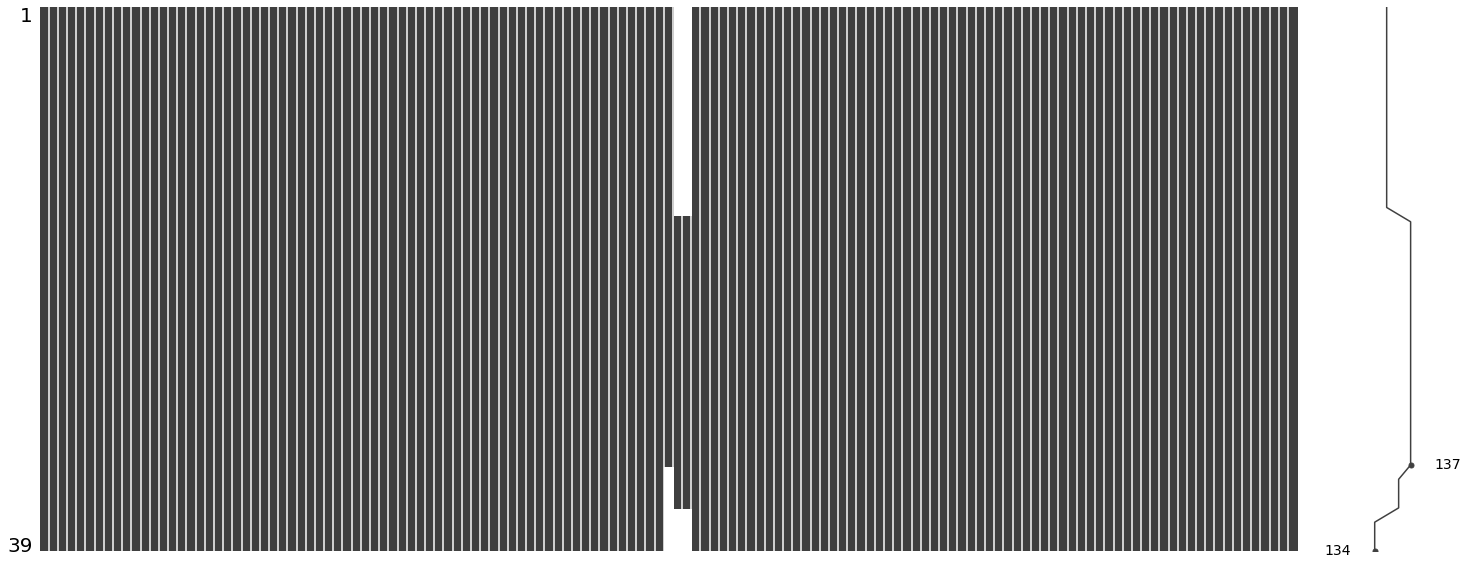

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,MIO_EUR,15.3846
1,L_TOTAL,46.1538
2,UNL_TOTAL,46.1538


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,0.437673,0.179965,-0.229370,-0.179965,0.436033,0.181755,-0.224968,-0.181755,0.057491,0.061168,0.053987,0.061168,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,14.890048,20.075834,9.704262,5.853562,25.471012,3.385105,4.405129,10.302935,10.681384,5.234830,7.665589,16.020175,16.544150,1.478329,1.076877,4.585695,4.818618,5.540972,167.297681,38.750565,76.831903,971.068914,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,5230.598616,0,3.882783,6.253010,10.321877,22.810674,0.365954,-0.165260,0.177493,-0.177493,0.371647,-0.169363,0.178929,-0.178929,0.065184,0.078587,0.080266,0.080266,3.882783,12.585331,22.720765,31.828054,0.449257,-0.252538,0.176848,-0.176848,0.451208,-0.249712,0.180750,-0.180750,0.059637,0.052054,0.063588,0.063588,3.882783,16.586862,27.566454,40.720656,0.468370,-0.285436,0.164908,-0.164908,0.469377,-0.280369,0.169654,-0.169654,0.059794,0.048069,0.063361,0.063361,3.882783,14.890048,27.566454,66.491666,0.437673,-0.229370,0.179965,-0.179965,0.436033,-0.224968,0.181755,-0.181755,0.057491,0.053987,0.061168,0.061168
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,0.383251,0.131294,-0.234086,-0.131294,0.349189,0.159533,-0.161820,-0.159533,0.049579,0.054829,0.040044,0.054829,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,16.777741,23.158666,10.396817,6.677373,28.496586,6.164893,6.682858,11.547467,11.962892,10.341826,10.872250,18.073805,18.637656,1.990602,2.485348,5.021128,5.288128,3.794415,114.687464,26.536070,52.833326,676.783218,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,4285.480144,9,6.047620,8.171462,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.047620,14.411227,25.050329,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.047620,18.645505,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988171,16.777741,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,0.431217,0.182427,-0.222728,-0.182427,0.419909,0.181693,-0.211698,-0.1

In [18]:
dataset_annual.cases.sum()

149

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

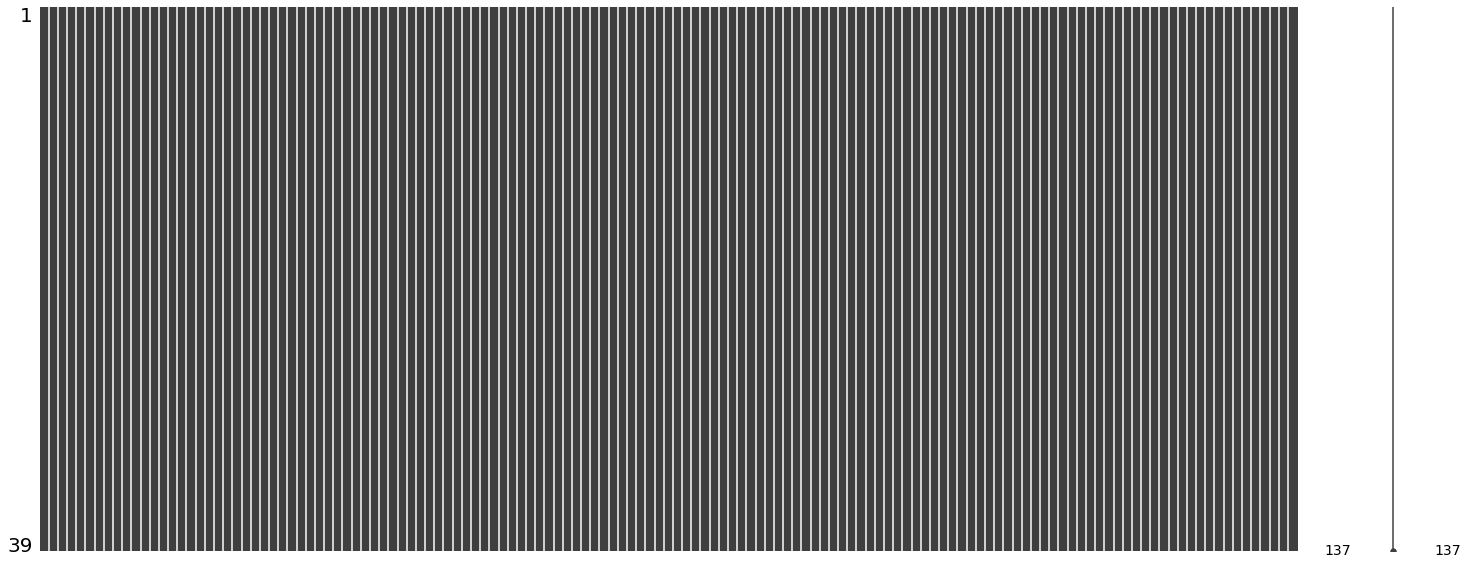

In [22]:
missingno.matrix(dataset_annual)

In [23]:
dataset_annual

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,0.437673,0.179965,-0.229370,-0.179965,0.436033,0.181755,-0.224968,-0.181755,0.057491,0.061168,0.053987,0.061168,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,14.890048,20.075834,9.704262,5.853562,25.471012,3.385105,4.405129,10.302935,10.681384,5.234830,7.665589,16.020175,16.544150,1.478329,1.076877,4.585695,4.818618,5.540972,167.297681,38.750565,76.831903,971.068914,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.130,10080.6,10176.8,5230.598616,0,3.882783,6.253010,10.321877,22.810674,0.365954,-0.165260,0.177493,-0.177493,0.371647,-0.169363,0.178929,-0.178929,0.065184,0.078587,0.080266,0.080266,3.882783,12.585331,22.720765,31.828054,0.449257,-0.252538,0.176848,-0.176848,0.451208,-0.249712,0.180750,-0.180750,0.059637,0.052054,0.063588,0.063588,3.882783,16.586862,27.566454,40.720656,0.468370,-0.285436,0.164908,-0.164908,0.469377,-0.280369,0.169654,-0.169654,0.059794,0.048069,0.063361,0.063361,3.882783,14.890048,27.566454,66.491666,0.437673,-0.229370,0.179965,-0.179965,0.436033,-0.224968,0.181755,-0.181755,0.057491,0.053987,0.061168,0.061168
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,0.383251,0.131294,-0.234086,-0.131294,0.349189,0.159533,-0.161820,-0.159533,0.049579,0.054829,0.040044,0.054829,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,16.777741,23.158666,10.396817,6.677373,28.496586,6.164893,6.682858,11.547467,11.962892,10.341826,10.872250,18.073805,18.637656,1.990602,2.485348,5.021128,5.288128,3.794415,114.687464,26.536070,52.833326,676.783218,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.450,6268.6,6460.0,4285.480144,9,6.047620,8.171462,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.047620,14.411227,25.050329,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.047620,18.645505,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988171,16.777741,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,0.431217,0.182427,-0.222728,-0.182427,0.419909,0.18169

In [24]:
dataset_annual[['year', 'NUTS3_NAME']].value_counts().sort_values(ascending=False)

year  NUTS3_NAME        
2010  καρδιτσα, τρικαλα     1
2013  λαρισα                1
2010  μαγνησια, σποραδες    1
2011  καρδιτσα, τρικαλα     1
      λαρισα                1
                           ..
2021  λαρισα                1
      μαγνησια, σποραδες    1
2022  καρδιτσα, τρικαλα     1
      λαρισα                1
      μαγνησια, σποραδες    1
Length: 39, dtype: int64

<AxesSubplot:>

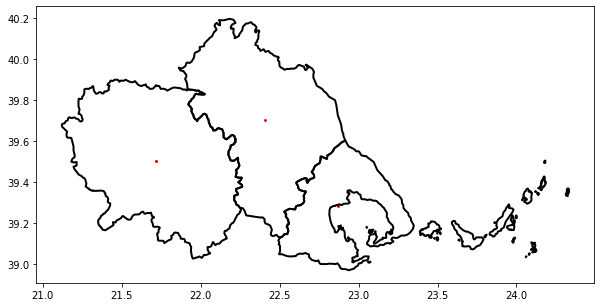

In [25]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [26]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [27]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,5.948136,8.265869,14.428439,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.247676,0.124756,0.332002,-0.332002,0.250039,0.109395,0.319940,-0.319940,0.050979,0.086203,0.061957,0.061957,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,14
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,7.672218,10.319188,10.048595,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,15
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,8.008002,10.354182,15.117940,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.337567,0.009852,0.289970,-0.289970,0.329326,0.020087,0.296028,-0.296028,0.046129,0.075248,0.053855,0.053855,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,4.630964,10.593495,14.288565,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.218565,0.035023,0.214999,-0.214999,0.210467,0.056554,0.228696,-0.228696,0.049441,0.090672,0.068613,0.068613,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,6.688539,12.883651,9.134991,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.227105,-0.092324,0.108107,-0.108107,0.228260,-0.110236,0.093846,-0.093846,0.048894,0.066280,0.057066,0.057066,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,2021,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.210389,8.090510,10.101309,16.054173,17.291667,22.250000,49.444444,888.169295,41.0,-4.0,45.0,15.833333,25.666667,28.333333,7.000000,1006.0,205.0,14.0,63.055735,412.0,156.0,178.0,202.0,0.395822,-0.336324,0.182778,-0.182778,0.378194,-0.323405,0.179100,-0.179100,0.061198,0.049147,0.067106,0.067106,135989.0,21482.0,85156.0,29351.0,144295.0,20120.0,88927.0,35248.0,3864.930,4121.0,5185.0,10578.321300,0
32,2021,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,6.336408,8.597620,9.954425,10.575433,16.875000,18.416667,47.222222,833.155284,38.0,-1.0,39.0,15.333333,27.000000,27.000000,7.333333,1052.0,250.0,14.0,73.900286,497.0,122.0,122.0,215.0,0.394613,-0.314786,0.219099,-0.219099,0.396634,-0.321884,0.218507,-0.218507,0.063717,0.056705,0.065415,0.065415,98350.0,13938.0,63669.0,20743.0,104051.0,13179.0,64890.0,25982.0,2354.660,6670.0,7132.0,1813.322917,0
33,2022,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,4.304143,5.340295,6.146828,11.77

In [28]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,11.693837,22.140834,22.319557,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.354872,-0.061508,0.257492,-0.257492,0.354794,-0.063112,0.255806,-0.255806,0.052500,0.065353,0.058403,0.058403,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,14
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,13.471987,24.971007,17.113235,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.358509,-0.115561,0.214682,-0.214682,0.360713,-0.113695,0.219722,-0.219722,0.045213,0.041865,0.050537,0.050537,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,15
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,13.287981,23.938267,23.164064,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.387653,-0.103838,0.241372,-0.241372,0.381755,-0.097753,0.244128,-0.244128,0.045229,0.056461,0.048786,0.048786,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,12.051599,25.365946,27.407604,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.339112,-0.121848,0.189366,-0.189366,0.333177,-0.109471,0.195944,-0.195944,0.054747,0.067724,0.065777,0.065777,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,14.084946,27.673564,20.044623,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.328231,-0.203309,0.107853,-0.107853,0.326772,-0.209213,0.101684,-0.101684,0.054389,0.050307,0.059957,0.059957,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,2021,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.210389,14.353319,24.963226,22.072766,17.291667,22.250000,49.444444,888.169295,41.0,-4.0,45.0,15.833333,25.666667,28.333333,7.000000,1006.0,205.0,14.0,63.055735,412.0,156.0,178.0,202.0,0.415942,-0.371745,0.142217,-0.142217,0.401490,-0.360250,0.139146,-0.139146,0.061307,0.046477,0.064777,0.064777,135989.0,21482.0,85156.0,29351.0,144295.0,20120.0,88927.0,35248.0,3864.930,4121.0,5185.0,10578.321300,0
32,2021,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,6.336408,14.151913,23.752319,16.549542,16.875000,18.416667,47.222222,833.155284,38.0,-1.0,39.0,15.333333,27.000000,27.000000,7.333333,1052.0,250.0,14.0,73.900286,497.0,122.0,122.0,215.0,0.435630,-0.366178,0.191640,-0.191640,0.432562,-0.367125,0.190779,-0.190779,0.061579,0.050052,0.061051,0.061051,98350.0,13938.0,63669.0,20743.0,104051.0,13179.0,64890.0,25982.0,2354.660,6670.0,7132.0,1813.322917,0
33,2022,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,4.304143,12.73

In [29]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,16.075582,26.194276,26.421316,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.397419,-0.147194,0.224026,-0.224026,0.396718,-0.146377,0.223808,-0.223808,0.056012,0.058159,0.061354,0.061354,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,14
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,18.121586,29.505567,22.503622,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.362258,-0.193909,0.155312,-0.155312,0.362993,-0.192573,0.158199,-0.158199,0.052767,0.039836,0.057991,0.057991,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,15
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,17.620242,27.951788,27.447041,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.406250,-0.171623,0.207952,-0.207952,0.401349,-0.167704,0.209458,-0.209458,0.050077,0.049983,0.052770,0.052770,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,16.693490,28.248765,32.928373,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.385594,-0.192493,0.174467,-0.174467,0.382494,-0.184611,0.179313,-0.179313,0.059209,0.057437,0.066948,0.066948,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,18.932507,30.892895,25.737431,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.338948,-0.251534,0.087278,-0.087278,0.337294,-0.255910,0.082401,-0.082401,0.060063,0.043734,0.063525,0.063525,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,2021,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.210389,18.864162,29.759256,27.827196,17.291667,22.250000,49.444444,888.169295,41.0,-4.0,45.0,15.833333,25.666667,28.333333,7.000000,1006.0,205.0,14.0,63.055735,412.0,156.0,178.0,202.0,0.390514,-0.363326,0.090385,-0.090385,0.382105,-0.356293,0.091042,-0.091042,0.062715,0.046057,0.065152,0.065152,135989.0,21482.0,85156.0,29351.0,144295.0,20120.0,88927.0,35248.0,3864.930,4121.0,5185.0,10578.321300,0
32,2021,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,6.336408,18.313418,28.284036,21.844752,16.875000,18.416667,47.222222,833.155284,38.0,-1.0,39.0,15.333333,27.000000,27.000000,7.333333,1052.0,250.0,14.0,73.900286,497.0,122.0,122.0,215.0,0.432682,-0.373784,0.166147,-0.166147,0.426418,-0.371645,0.162577,-0.162577,0.063069,0.048691,0.061782,0.061782,98350.0,13938.0,63669.0,20743.0,104051.0,13179.0,64890.0,25982.0,2354.660,6670.0,7132.0,1813.322917,0
33,2022,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,4.304143,16.45

In [30]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,14.301585,26.194276,40.415159,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.380764,-0.151949,0.199359,-0.199359,0.379643,-0.151105,0.199373,-0.199373,0.056902,0.064875,0.064113,0.064113,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,14
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,16.242293,29.505567,30.736684,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.339338,-0.210817,0.113893,-0.113893,0.338700,-0.209326,0.115652,-0.115652,0.052172,0.045425,0.059106,0.059106,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,15
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,15.982300,27.951788,35.960870,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.389605,-0.164112,0.194131,-0.194131,0.384087,-0.159440,0.195163,-0.195163,0.051306,0.056083,0.055047,0.055047,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,15.132808,28.248765,58.935762,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.384220,-0.168638,0.188761,-0.188761,0.381591,-0.162976,0.192204,-0.192204,0.060136,0.063517,0.067541,0.067541,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,17.294664,30.892895,42.177040,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.340094,-0.261657,0.071960,-0.071960,0.337629,-0.264379,0.067848,-0.067848,0.059165,0.045515,0.062994,0.062994,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,2021,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.210389,19.382385,29.759256,43.194426,17.291667,22.250000,49.444444,888.169295,41.0,-4.0,45.0,15.833333,25.666667,28.333333,7.000000,1006.0,205.0,14.0,63.055735,412.0,156.0,178.0,202.0,0.379455,-0.351635,0.091645,-0.091645,0.373835,-0.347557,0.091730,-0.091730,0.060393,0.044555,0.063260,0.063260,135989.0,21482.0,85156.0,29351.0,144295.0,20120.0,88927.0,35248.0,3864.930,4121.0,5185.0,10578.321300,0
32,2021,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,6.336408,18.628544,28.284036,37.845835,16.875000,18.416667,47.222222,833.155284,38.0,-1.0,39.0,15.333333,27.000000,27.000000,7.333333,1052.0,250.0,14.0,73.900286,497.0,122.0,122.0,215.0,0.437775,-0.379354,0.163657,-0.163657,0.431642,-0.377481,0.159431,-0.159431,0.063270,0.048293,0.062517,0.062517,98350.0,13938.0,63669.0,20743.0,104051.0,13179.0,64890.0,25982.0,2354.660,6670.0,7132.0,1813.322917,0
33,2022,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,4.304143,15.34

In [31]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

140
140
140
140


In [32]:
df_q1 = convert_multiple_cases(df_q1, target_col='WNV_cases')
df_q2 = convert_multiple_cases(df_q2, target_col='WNV_cases')
df_q3 = convert_multiple_cases(df_q3, target_col='WNV_cases')
df_q4 = convert_multiple_cases(df_q4, target_col='WNV_cases')

In [33]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

140
140
140
140


In [34]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,5.948136,8.265869,14.428439,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.247676,0.124756,0.332002,-0.332002,0.250039,0.109395,0.319940,-0.319940,0.050979,0.086203,0.061957,0.061957,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,7.672218,10.319188,10.048595,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,8.008002,10.354182,15.117940,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.337567,0.009852,0.289970,-0.289970,0.329326,0.020087,0.296028,-0.296028,0.046129,0.075248,0.053855,0.053855,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,4.630964,10.593495,14.288565,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.218565,0.035023,0.214999,-0.214999,0.210467,0.056554,0.228696,-0.228696,0.049441,0.090672,0.068613,0.068613,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,6.688539,12.883651,9.134991,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.227105,-0.092324,0.108107,-0.108107,0.228260,-0.110236,0.093846,-0.093846,0.048894,0.066280,0.057066,0.057066,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,6.581947,7.403107,12.675841,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.127453,-0.127453,0.060245,0.050407,0.065043,0.065043,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
162,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,6.581947,7.403107,12.675841,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.127453,-0.127453,0.060245,0.050407,0.065043,0.065043,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
163,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,6.581947,7.403107,12.675841,18.250000,22.166667,

In [35]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,11.693837,22.140834,22.319557,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.354872,-0.061508,0.257492,-0.257492,0.354794,-0.063112,0.255806,-0.255806,0.052500,0.065353,0.058403,0.058403,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,13.471987,24.971007,17.113235,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.358509,-0.115561,0.214682,-0.214682,0.360713,-0.113695,0.219722,-0.219722,0.045213,0.041865,0.050537,0.050537,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,13.287981,23.938267,23.164064,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.387653,-0.103838,0.241372,-0.241372,0.381755,-0.097753,0.244128,-0.244128,0.045229,0.056461,0.048786,0.048786,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,12.051599,25.365946,27.407604,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.339112,-0.121848,0.189366,-0.189366,0.333177,-0.109471,0.195944,-0.195944,0.054747,0.067724,0.065777,0.065777,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,14.084946,27.673564,20.044623,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.328231,-0.203309,0.107853,-0.107853,0.326772,-0.209213,0.101684,-0.101684,0.054389,0.050307,0.059957,0.059957,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,14.227463,27.536030,22.933007,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.404737,-0.363558,0.122827,-0.122827,0.391423,-0.351654,0.125106,-0.125106,0.059276,0.046457,0.063936,0.063936,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
162,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,14.227463,27.536030,22.933007,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.404737,-0.363558,0.122827,-0.122827,0.391423,-0.351654,0.125106,-0.125106,0.059276,0.046457,0.063936,0.063936,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
163,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,14.227463,27.536030,22.933007

In [36]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,16.075582,26.194276,26.421316,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.397419,-0.147194,0.224026,-0.224026,0.396718,-0.146377,0.223808,-0.223808,0.056012,0.058159,0.061354,0.061354,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,18.121586,29.505567,22.503622,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.362258,-0.193909,0.155312,-0.155312,0.362993,-0.192573,0.158199,-0.158199,0.052767,0.039836,0.057991,0.057991,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,17.620242,27.951788,27.447041,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.406250,-0.171623,0.207952,-0.207952,0.401349,-0.167704,0.209458,-0.209458,0.050077,0.049983,0.052770,0.052770,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,16.693490,28.248765,32.928373,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.385594,-0.192493,0.174467,-0.174467,0.382494,-0.184611,0.179313,-0.179313,0.059209,0.057437,0.066948,0.066948,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,18.932507,30.892895,25.737431,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.338948,-0.251534,0.087278,-0.087278,0.337294,-0.255910,0.082401,-0.082401,0.060063,0.043734,0.063525,0.063525,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,18.380755,28.484998,33.850996,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651,0.388426,-0.356267,0.091034,-0.091034,0.060048,0.045394,0.064120,0.064120,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
162,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,18.380755,28.484998,33.850996,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651,0.388426,-0.356267,0.091034,-0.091034,0.060048,0.045394,0.064120,0.064120,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
163,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,18.380755,28.484998,33.850996

In [37]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,14.301585,26.194276,40.415159,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.380764,-0.151949,0.199359,-0.199359,0.379643,-0.151105,0.199373,-0.199373,0.056902,0.064875,0.064113,0.064113,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,16.242293,29.505567,30.736684,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.339338,-0.210817,0.113893,-0.113893,0.338700,-0.209326,0.115652,-0.115652,0.052172,0.045425,0.059106,0.059106,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,15.982300,27.951788,35.960870,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.389605,-0.164112,0.194131,-0.194131,0.384087,-0.159440,0.195163,-0.195163,0.051306,0.056083,0.055047,0.055047,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,15.132808,28.248765,58.935762,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.384220,-0.168638,0.188761,-0.188761,0.381591,-0.162976,0.192204,-0.192204,0.060136,0.063517,0.067541,0.067541,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,17.294664,30.892895,42.177040,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.340094,-0.261657,0.071960,-0.071960,0.337629,-0.264379,0.067848,-0.067848,0.059165,0.045515,0.062994,0.062994,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.730,6268.6,6460.0,4641.090253,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,17.149202,28.484998,36.243313,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.370733,-0.339116,0.064168,-0.064168,0.361031,-0.329690,0.068150,-0.068150,0.057495,0.044997,0.061937,0.061937,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
162,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,17.149202,28.484998,36.243313,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.370733,-0.339116,0.064168,-0.064168,0.361031,-0.329690,0.068150,-0.068150,0.057495,0.044997,0.061937,0.061937,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
163,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,17.149202,28.484998,36.243313

In [38]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2011_2022.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2011_2022.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2011_2022.csv", encoding = enc, index = False)